# This is a script used to plot the temp change as strips


In [21]:
import xarray as xr
import numpy as np
import pandas as pd

In [22]:

variables = ["tas","precip","evap","soiltemp","sm","snowdepth","LAI_PFT","windspeed","iceconc","ice_sheet"]
units = ["degC", "mm month^-1", "mm month^-1", "degC", "kg m^-1", "mm", "leaf area index LAI", "m s^-1", "%"," "]  # Units for each variable
longnames = [
    "2m Air Temperature",
    "Surface Precipitation",
    "Evapotranspiration",
    "Soil Temperature from top layer",
    "Soil Moisture from top layer",
    "Snow Depth",
    "Leaf Area Index (LAI)",
    "10m Wind Speed",
    "Sea Ice Concentration",
    "Ice Sheet 0/1"
]  # Long names for each variable
# scenarios=["natural","SSP126","SSP245","SSP370","SSP460","SSP534","SSP585"]
scenarios = ["natural","SSP126","SSP245","SSP370","SSP585","10000PGC"]  # or "historical"

site = "LA"
downscaled = False    # Set to True if downscaled data is used, False otherwise
var = 0


# now read in the data

In [23]:
data_path = "site_data/"

def load_data_for_scenario(scen):
    if downscaled:
        data_file = f"downscaled/{variables[var]}_{scenarios[scen]}_site_{site}_downscaled.txt"
    else:
        data_file = f"site_{site}/{variables[var]}_{scenarios[scen]}_site_{site}.txt"
    
    print("Loading data from:", data_file)
    data = np.loadtxt(data_path + data_file)
    print(f"shape of data for {scenarios[scen]}:", data.shape)
    return data


# Start data process


In [24]:
warm_threshold = -3.0  # Define a threshold for warm temperature
cold_threshold = -5.0  # Define a threshold for cold temperature
if downscaled:
    warm_threshold = 6.0  # Adjust threshold for downscaled data
    cold_threshold = 2.0  # Adjust threshold for downscaled data

def process_data(data):
    # Calculate the number of members with values over warm_threshold and below cold_threshold for each time step
    warm_mem = np.sum(data > warm_threshold, axis=0)
    cold_mem = np.sum(data < cold_threshold, axis=0)
    
    midd_mem = np.sum((data <= warm_threshold) & (data >= cold_threshold), axis=0)
    
    # Check if the sum of warm_mem, cold_mem, and midd_mem equals total members for each time step
    total_mem = warm_mem + cold_mem + midd_mem
    if not np.all(total_mem == data.shape[0]):
        raise ValueError(f"Error: The sum of warm_mem, cold_mem, and midd_mem is not {data.shape[0]} for all time steps.")
    
    return warm_mem, cold_mem, midd_mem

# Load and process data for all scenarios
all_data = {}
all_processed = {}
for scen_idx in range(len(scenarios)):
    all_data[scen_idx] = load_data_for_scenario(scen_idx)
    all_processed[scen_idx] = process_data(all_data[scen_idx])


Loading data from: site_LA/tas_natural_site_LA.txt
shape of data for natural: (90, 1001)
Loading data from: site_LA/tas_SSP126_site_LA.txt
shape of data for SSP126: (90, 1001)
Loading data from: site_LA/tas_SSP245_site_LA.txt
shape of data for SSP245: (90, 1001)
Loading data from: site_LA/tas_SSP370_site_LA.txt
shape of data for SSP370: (90, 1001)
Loading data from: site_LA/tas_SSP585_site_LA.txt
shape of data for SSP585: (90, 1001)
Loading data from: site_LA/tas_10000PGC_site_LA.txt
shape of data for 10000PGC: (90, 1001)


# Start to plot

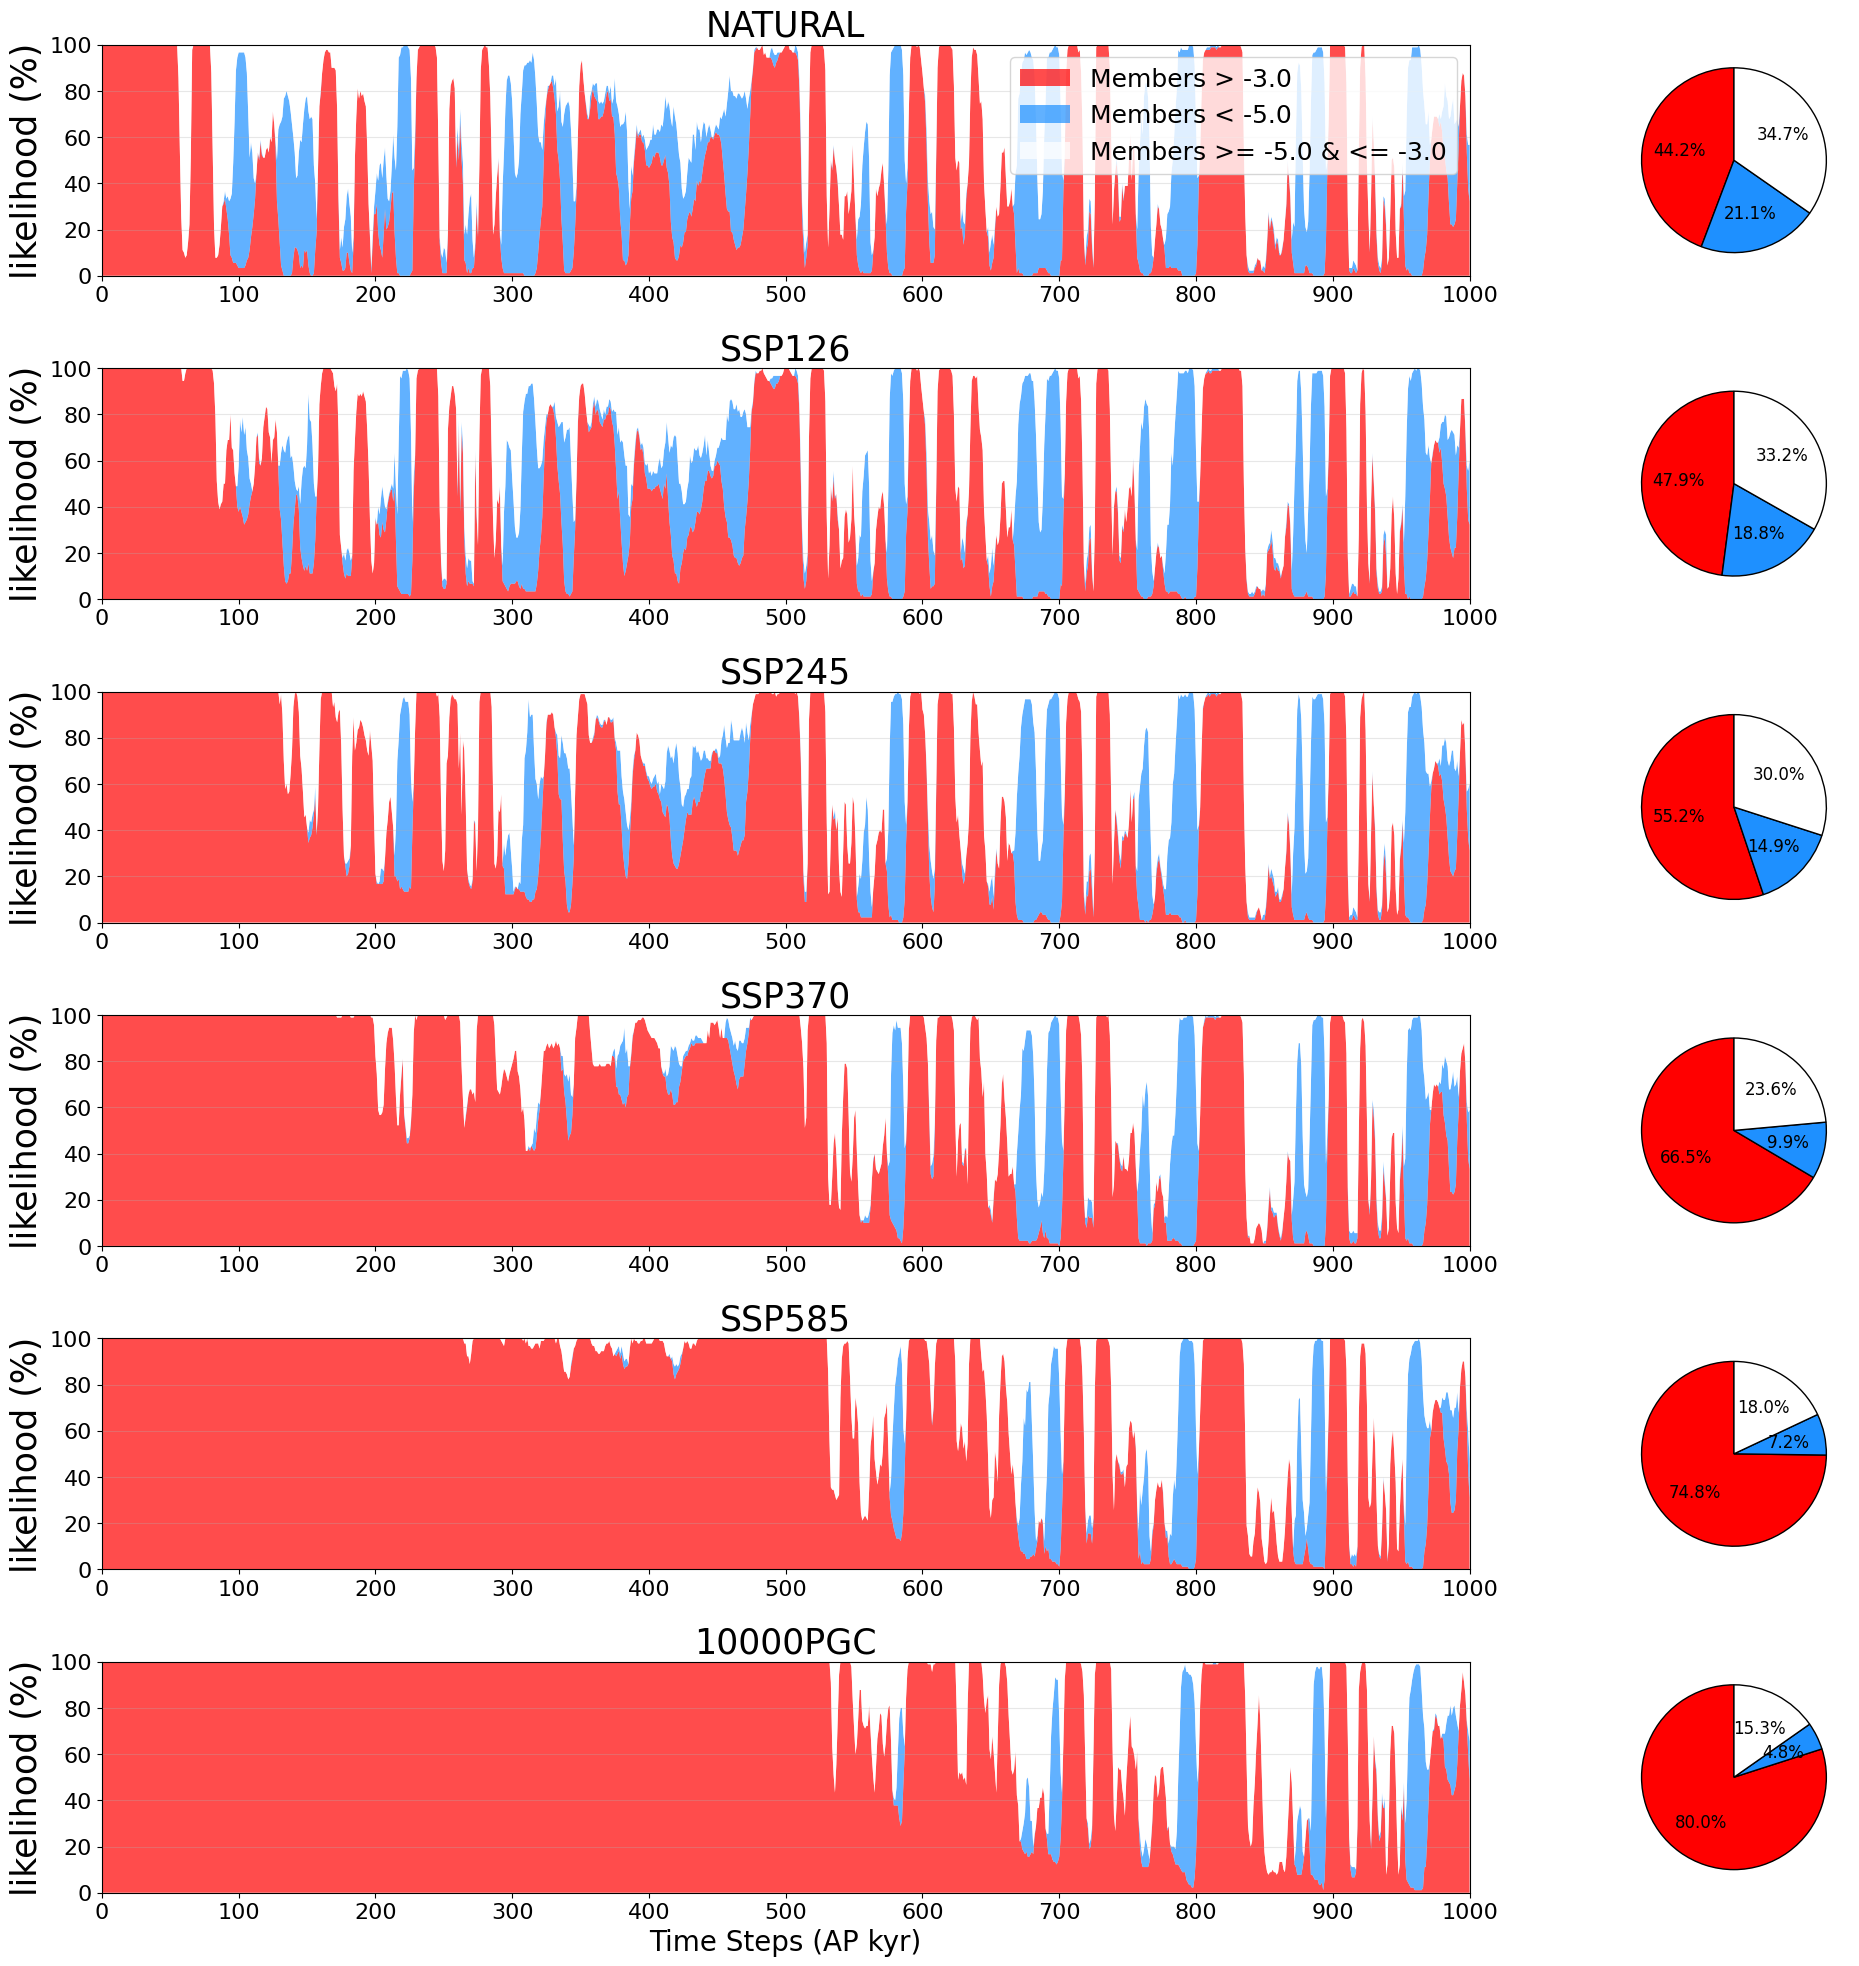

In [26]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Create time steps array
time_steps = np.arange(all_data[0].shape[1])

# Create a figure with subplots: 2 columns per scenario (stacked area + pie chart)
n_scen = len(scenarios)
fig = plt.figure(figsize=(24, 4 * n_scen))
gs = GridSpec(n_scen, 2, figure=fig, width_ratios=[3, 1], hspace=0.4, wspace=0.04)

for scen_idx, scenario in enumerate(scenarios):
    warm_mem, cold_mem, midd_mem = all_processed[scen_idx]
    
    # Convert to percentages
    total_mem = warm_mem + cold_mem + midd_mem
    warm_pct = 100 * warm_mem / total_mem
    cold_pct = 100 * cold_mem / total_mem
    midd_pct = 100 * midd_mem / total_mem
    
    # Left subplot: stacked area plot
    ax1 = fig.add_subplot(gs[scen_idx, 0])
    ax1.stackplot(
        time_steps, warm_pct, cold_pct, midd_pct,
        colors=['red', 'dodgerblue', 'white'], alpha=0.7
    )
    
    # Add legend only for the first scenario
    if scen_idx == 0:
        ax1.legend(
            [f'Members > {warm_threshold}', f'Members < {cold_threshold}', f'Members >= {cold_threshold} & <= {warm_threshold}'],
            loc='upper right', fontsize=18
        )
    
    ax1.set_xlim(0, 1000)
    ax1.set_xticks(time_steps[::100])
    ax1.set_xticklabels(time_steps[::100], fontsize=16)
    ax1.tick_params(axis='y', labelsize=16)
    ax1.set_ylabel('likelihood (%)', fontsize=25)
    ax1.set_ylim(0, 100)
    ax1.set_title(f'{scenario.upper()}', fontsize=25)
    ax1.grid(axis='y', alpha=0.3)
    if scen_idx == n_scen - 1:
        ax1.set_xlabel('Time Steps (AP kyr)', fontsize=20)
    
    # Right subplot: pie chart
    ax2 = fig.add_subplot(gs[scen_idx, 1])
    sizes = [np.sum(warm_mem), np.sum(cold_mem), np.sum(midd_mem)]
    labels = [f'Members > {warm_threshold}', f'Members < {cold_threshold}', f'Members >= {cold_threshold} & <= {warm_threshold}']
    colors = ['red', 'dodgerblue', 'white']
    ax2.pie(
        sizes, colors=colors, autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 12}, wedgeprops={'edgecolor': 'black', 'linewidth': 1},
        labeldistance=1.0
    )

plt.savefig(f"plots/{variables[var]}_site_{site}_stackplot_with_pie.png", dpi=300, bbox_inches='tight')
plt.show()
